# 4 — Statistical modelling

**Inputs:**

| File | Contents |
|---|---|
| `data/curated/model_table.parquet` | The airport-hour table: both targets, the split, and every flag. |
| `data/curated/model_table_roles.json` | The feature list and the leakage contract, read rather than hardcoded. |

**Outputs:** `models/` (both fitted models and the coefficient table),
`data/curated/model_predictions.parquet`, `data/curated/model_results.json`, and three
figures in `plots/`.

## Two models

| | Model 1 | Model 2 |
|---|---|---|
| Target | `n_pickups` (count) | `mean_total` (US$, continuous) |
| Family | Poisson GLM, log link, quasi-Poisson scale [1] | Gradient-boosted regression trees [3] |
| Nature | Parametric, read as rate ratios | Non-parametric, captures interactions |
| Missing data | Needs a complete design matrix | Handled natively |
| Benchmark | Seasonal naive: last week, same hour | Seasonal naive: last week, same hour |

Their **product** is expected revenue per airport-hour. Notebook 2c asserted that
`n_pickups × mean_total = sum_total_amount` holds row by row to the cent.

## Flow

0. Load the table and the roles manifest.
1. Build the modelling set and the two splits.
2. Assemble each model's feature list and assert no same-hour outcome reaches it.
3. Fit Model 1: imputation, standardisation, the Poisson and quasi-Poisson fits, a rank
   check on the design, and a negative binomial contrast.
4. Fit Model 2: freeze the categorical levels, tune on a forward validation split, refit on
   the whole training year, and score against the benchmark on their common support.
5. Compare the models and analyse the errors.
6. Combine the two into expected revenue, measure the omitted covariance term, and refit
   Model 2 weighted by `n_pickups` as a refinement.
7. Read the combined surface off by hour and day.
8. Persist the models, predictions, and results.

## Rules this notebook holds itself to

- **Prediction runs forward in time.** Train is 2023, test is January–June 2024, read from
  the `split` column 2c materialised. The validation split used to choose the boosting
  hyper-parameters is the last quarter of the training year, not a random subset.
- **No feature may be a same-hour outcome.** The assertion in Step 2 fails the run if one
  reaches a feature list.
- **Standardisation and imputation are fitted on the training split alone**, then applied to
  the test split.


In [1]:
"""Fit, compare, and combine the two models.

Model 1 is a Poisson GLM with a quasi-Poisson scale for the pickup count;
Model 2 is a gradient-boosted tree ensemble for the mean fare. Their product is
expected revenue per airport-hour.

Reads the feature list and the leakage contract from `model_table_roles.json`
rather than hardcoding them.
"""

import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.colors import TwoSlopeNorm
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_poisson_deviance

sys.path.append(str(Path("..") / "scripts"))
from plot_utils import (  # noqa: E402
    BASELINE_COLOUR,
    DIVERGING_CMAP,
    PALETTE,
    airport_colour,
    currency_axis,
    heatmap,
    new_figure,
    save_figure,
    set_plot_style,
)

# --- Paths -----------------------------------------------------------------
# Notebook is expected to run from `notebooks/`.
PROJECT_ROOT = Path("..").resolve()
CURATED_DIR = PROJECT_ROOT / "data" / "curated"
MODELS_DIR = PROJECT_ROOT / "models"
PLOTS_DIR = PROJECT_ROOT / "plots"
for directory in (MODELS_DIR, PLOTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# --- Reproducibility -------------------------------------------------------
SEED = 42

# --- The tuning split ------------------------------------------------------
# Hyper-parameters are chosen on the last quarter of the training year, then
# refitted on the whole of it. A split in time, not a random one.
TUNE_VALID_START = "2023-10-01"

# Spark is not used here: the model table is small enough to fit in pandas,
# which is what both model libraries want.
set_plot_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## Step 0 — Load the table and the contract

The roles manifest is the interface between 2c and this notebook: reading the feature list
from it rather than retyping column names means an upstream rename either propagates here
automatically or fails loudly.

The benchmark 2c fixed before any model was fitted is printed here for reference.


In [2]:
table = pd.read_parquet(CURATED_DIR / "model_table.parquet")
table["date"] = pd.to_datetime(table["date"])

with open(CURATED_DIR / "model_table_roles.json") as handle:
    roles = json.load(handle)

assert len(table) == roles["rows"], (
    f"{len(table):,} rows read, manifest declares {roles['rows']:,}"
)

TARGET_VOLUME = roles["targets"]["model_1_volume"]
TARGET_VALUE = roles["targets"]["model_2_value"]
benchmark = roles["benchmark"]

AIRPORTS = tuple(sorted(table["airport"].unique()))

# Step 5 keys two airport-specific explanations by name, so a change of
# scope must fail here rather than mislabel them further down.
assert set(AIRPORTS) == {"JFK", "LGA"}, (
    f"Step 5 names JFK and LGA explicitly; this table carries {AIRPORTS}"
)

print(f"{len(table):,} rows × {len(table.columns)} columns")
print(f"Airports: {', '.join(AIRPORTS)}")
print(f"Targets: {TARGET_VOLUME} (Model 1), {TARGET_VALUE} (Model 2)")
print("\nSeasonal-naive benchmark to beat, fixed in 2c before any model was fitted:")
print(f"  {TARGET_VOLUME:<12} RMSE {benchmark['test_rmse_pickups']:>7.2f} pickups   "
      f"MAE {benchmark['test_mae_pickups']:>6.2f}")
print(f"  {TARGET_VALUE:<12} RMSE ${benchmark['test_rmse_mean_total']:>6.2f}   "
      f"MAE ${benchmark['test_mae_mean_total']:>5.2f}")

26,256 rows × 79 columns
Airports: JFK, LGA
Targets: n_pickups (Model 1), mean_total (Model 2)

Seasonal-naive benchmark to beat, fixed in 2c before any model was fitted:
  n_pickups    RMSE   52.84 pickups   MAE  36.08
  mean_total   RMSE $ 10.13   MAE $ 5.18


## Step 1 — The modelling set

Two exclusions, both flagged upstream rather than decided here:

- **`dst_anomaly`** — six rows: the 02:00 that does not exist on the spring-forward dates,
  and the 01:00 that occurs twice in November and holds two clock hours of trips.
- **`has_full_lags` false** — the first week of 2023, whose weekly lag does not exist. These
  are excluded from the *fit*; notebook 3 used them, because a distribution should describe
  the whole window.

Model 2's support is smaller than Model 1's, since `mean_total` is undefined in hours with
no pickups. The gap is reported here rather than discovered in a row count later.

The count benchmark 2c computed matches Model 1's row set exactly. The value benchmark does
not — it is undefined wherever the same hour last week was empty — so Step 4 recomputes both
on their common support.


In [3]:
usable = table[table["has_full_lags"] & ~table["dst_anomaly"]].copy()

train = usable[usable["split"] == "train"].sort_values(["airport", "date", "hour"])
test = usable[usable["split"] == "test"].sort_values(["airport", "date", "hour"])

excluded = len(table) - len(usable)
print(f"Excluded from the fit: {excluded} rows "
      f"({int(table['dst_anomaly'].sum())} daylight-saving, "
      f"{int((~table['has_full_lags']).sum())} without a weekly lag)")
print(f"train  {len(train):,} rows  ({train['date'].min().date()} to "
      f"{train['date'].max().date()})")
print(f"test   {len(test):,} rows  ({test['date'].min().date()} to "
      f"{test['date'].max().date()})")

# Every test date must follow every training date.
assert train["date"].max() < test["date"].min(), "The split is not forward in time"
assert len(train) + len(test) == len(usable)

# Model 2 is undefined where no trip occurred, so its support is smaller.
value_train = train[train[TARGET_VALUE].notna()]
value_test = test[test[TARGET_VALUE].notna()]
print(f"\nModel 2 support: {len(value_train):,} train / {len(value_test):,} test "
      f"rows where {TARGET_VALUE} is defined "
      f"({len(train) - len(value_train)} and {len(test) - len(value_test)} "
      "empty hours dropped)")

Excluded from the fit: 342 rows (6 daylight-saving, 336 without a weekly lag)
train  17,180 rows  (2023-01-08 to 2023-12-31)
test   8,734 rows  (2024-01-01 to 2024-06-30)

Model 2 support: 16,375 train / 8,375 test rows where mean_total is defined (805 and 359 empty hours dropped)


## Step 2 — Features, and the leakage check

The manifest groups features by kind because the two models take different subsets:

- **Both models** take the calendar, the published arrival schedule, the Newark context, the
  weather, and the one-hour-lagged realised flight and taxi columns.
- **Model 1** additionally takes the volume history (`pickups_lag_*`).
- **Model 2** additionally takes the value history (`mean_total_lag_*`).

Neither takes the other's target history, so that the product of the two predictions does
not double-count one signal.

The manifest's `cyclical` pair, `hour_sin` and `hour_cos`, is used by neither model; Step 3
says why. Two further declared features are dropped from the GLM design only, and not from
the trees: `is_weekend`, which is an exact function of the day-of-week dummies, and
`arrival_slippage_lag_1h`, which satisfies
`arrival_slippage_lag_1h = actual_arrivals_lag_1h − sched_arrivals_prev_hr` exactly in every
row. Both would make the design matrix rank deficient.

The assertion is the point of this cell: if any column listed under `leak_if_unlagged`
reaches a feature list, the run stops here.


In [4]:
groups = roles["features"]
leak_if_unlagged = set(roles["leak_if_unlagged"])

SHARED_GROUPS = [
    "temporal", "categorical", "flight_schedule", "flight_realised_lagged",
    "ewr", "weather", "taxi_lagged",
]


def collect(group_names: list) -> list:
    """Flatten feature groups into an ordered, de-duplicated list.

    ``temporal`` and ``categorical`` overlap in the manifest, so a plain
    concatenation would repeat ``day_of_week`` and ``month``.

    Args:
        group_names: Keys of the manifest's ``features`` mapping.

    Returns:
        Feature names, first occurrence order preserved.
    """
    seen, ordered = set(), []
    for name in group_names:
        for column in groups[name]:
            if column not in seen:
                seen.add(column)
                ordered.append(column)
    return ordered


MODEL_1_FEATURES = collect(SHARED_GROUPS + ["lags_volume"])
MODEL_2_FEATURES = collect(SHARED_GROUPS + ["lags_value"])

for name, features in [("Model 1", MODEL_1_FEATURES), ("Model 2", MODEL_2_FEATURES)]:
    leaking = sorted(set(features) & leak_if_unlagged)
    assert not leaking, f"{name} would use same-hour outcomes: {leaking}"
    absent = [column for column in features if column not in table.columns]
    assert not absent, f"{name} declares features absent from the table: {absent}"
    print(f"{name}: {len(features)} features")

print("\nNo same-hour outcome reaches either feature list.")
print(f"({len(leak_if_unlagged)} columns are barred by the manifest.)")

Model 1: 39 features
Model 2: 37 features

No same-hour outcome reaches either feature list.
(23 columns are barred by the manifest.)


## Step 3 — Model 1: a Poisson GLM for demand

The response is a non-negative integer count with a hard floor at zero and a strongly
right-skewed conditional distribution, which is what a Poisson GLM with a log link is for
[1]. Under the log link a coefficient is a **rate ratio**, which is the form the report
quotes.

### The design

- **Hour enters as 23 dummies interacted with airport**, rather than as the cyclical terms
  the manifest also offers, so that the two airports can have different daily shapes.
- **Day of week and month enter as dummies**, since neither is a quantity.
- **Continuous features are standardised** on the training split, so a coefficient is the
  effect of a one-standard-deviation move.
- **The design is checked for identification after the fit.** `statsmodels` does not raise
  on a rank-deficient design: it falls back to a pseudo-inverse and returns a minimum-norm
  solution whose individual coefficients and standard errors are artefacts. Predictions are
  unaffected; the quoted rate ratios would not be. The assertion after the fit compares the
  design's rank with its column count.

### Assumptions, stated before the fit

1. Observations are conditionally independent given the features. The residual
   autocorrelation is checked in Step 5.
2. The variance is proportional to the mean. Notebook 3 found the conditional ratio above
   one, so the **quasi-Poisson** scale is used: the Pearson chi-squared statistic divided by
   its degrees of freedom multiplies the standard errors. Point predictions are unaffected.
3. No same-hour outcome is in the design, enforced in Step 2.

### Imputation, fitted on training data only

A GLM needs a complete design matrix, so three families of structural null are resolved:

| Family | Columns | Fill |
|---|---|---|
| Nothing scheduled to land | `share_longhaul`, the lagged cancellation and delay shares | 0 |
| Window edge | `sched_arrivals_prev_hr`, `sched_arrivals_next_hr` | 0 |
| Weather gap | `temp_c`, `rhum_pct`, `wspd_kmh`, `pres_hpa` | Training median |


In [5]:
# Zero-filled: each is a statistic of an empty set rather than an unknown
# value.
STRUCTURAL_ZERO = [
    "share_longhaul",
    "sched_arrivals_prev_hr",
    "sched_arrivals_next_hr",
    "share_cancelled_lag_1h",
    "share_delayed_15_lag_1h",
    "mean_arr_delay_min_lag_1h",
    "n_delay_observed_lag_1h",
    "arrival_slippage_lag_1h",
    "actual_arrivals_lag_1h",
    "ewr_share_cancelled_lag_1h",
    "ewr_mean_arr_delay_min_lag_1h",
    "ewr_n_delay_observed_lag_1h",
]

# Median-filled: the measurement exists but was not recorded, and the
# quantity is smooth.
MEDIAN_FILL = ["temp_c", "rhum_pct", "wspd_kmh", "pres_hpa", "prcp_mm"]

# The taxi-side lags are undefined for an hour that had no trips, so they are
# median-filled too.
LAG_MEDIAN_FILL = [
    "mean_fare_lag_1h", "share_flat_fare_lag_1h", "mean_distance_mi_lag_1h",
    "mean_tip_ratio_lag_1h", "share_flex_fare_lag_1h", "mean_total_lag_168h",
    "mean_total_same_hour_7d",
]

BOOLEAN_FEATURES = [
    "is_weekend", "is_holiday", "is_holiday_adjacent", "is_precip", "is_freezing",
]


def fit_imputer(frame: pd.DataFrame, columns: list) -> dict:
    """Learn median fill values from the training split.

    Args:
        frame: Training rows only, so the fill cannot see the test split.
        columns: Columns to learn a median for.

    Returns:
        Mapping from column name to the training median.
    """
    return {
        column: float(frame[column].median())
        for column in columns
        if column in frame.columns
    }


def apply_imputation(
    frame: pd.DataFrame, medians: dict, features: list
) -> pd.DataFrame:
    """Resolve the documented null families in a copy of ``frame``.

    Args:
        frame: Rows to impute.
        medians: Fill values from :func:`fit_imputer`.
        features: Feature columns that must be complete afterwards.

    Returns:
        A copy with no nulls in ``features``.

    Raises:
        AssertionError: If a feature still holds a null, meaning an
            undocumented null family reached this notebook.
    """
    filled = frame.copy()
    for column in STRUCTURAL_ZERO:
        if column in filled.columns:
            filled[column] = filled[column].fillna(0.0)
    for column, value in medians.items():
        filled[column] = filled[column].fillna(value)
    for column in BOOLEAN_FEATURES:
        if column in filled.columns:
            filled[column] = filled[column].fillna(False).astype(bool)

    remaining = [
        column for column in features if filled[column].isna().any()
    ]
    assert not remaining, f"Undocumented nulls survive imputation in: {remaining}"
    return filled


medians = fit_imputer(train, MEDIAN_FILL + LAG_MEDIAN_FILL)
glm_train = apply_imputation(train, medians, MODEL_1_FEATURES)
glm_test = apply_imputation(test, medians, MODEL_1_FEATURES)

print(f"Median fills learned from {len(train):,} training rows only:")
for column, value in list(medians.items())[:5]:
    print(f"  {column:<26} {value:.2f}")
print(f"  ... {len(medians)} columns in total")

Median fills learned from 17,180 training rows only:
  temp_c                     13.90
  rhum_pct                   64.00
  wspd_kmh                   16.60
  pres_hpa                   1015.70
  prcp_mm                    0.00
  ... 12 columns in total


In [6]:
# Standardisation, on the training split alone. Binary and categorical
# columns are left as they are.
CATEGORICAL = ["hour", "day_of_week", "month", "airport"]

# Dropped from the GLM design only, not from the manifest and not from the
# trees. The identity
#
#     arrival_slippage_lag_1h == actual_arrivals_lag_1h - sched_arrivals_prev_hr
#
# holds exactly in every row, so the three columns carry two degrees of
# freedom and leaving all three in makes the design rank deficient. The two
# columns the difference was built from are kept.
ALIASED_IN_GLM = ["arrival_slippage_lag_1h"]

CONTINUOUS = [
    column for column in MODEL_1_FEATURES
    if column not in CATEGORICAL + BOOLEAN_FEATURES + ALIASED_IN_GLM
]

scaler = {
    column: (float(glm_train[column].mean()), float(glm_train[column].std(ddof=0)))
    for column in CONTINUOUS
}


def standardise(frame: pd.DataFrame, statistics: dict) -> pd.DataFrame:
    """Centre and scale continuous columns with training statistics.

    Args:
        frame: Rows to transform.
        statistics: Mapping from column to ``(mean, standard deviation)``,
            learned on the training split.

    Returns:
        A copy in which each continuous column is expressed in training
        standard deviations. A column with no variation in training is left
        centred but unscaled rather than divided by zero.
    """
    scaled = frame.copy()
    for column, (centre, spread) in statistics.items():
        scaled[column] = (scaled[column] - centre) / (spread if spread > 0 else 1.0)
    return scaled


glm_train = standardise(glm_train, scaler)
glm_test = standardise(glm_test, scaler)

# `is_weekend` is an exact function of the day-of-week dummies, so it is
# absent here too.
GLM_TERMS = (
    ["C(hour) * airport", "C(day_of_week)", "C(month)"]
    + ["is_holiday", "is_holiday_adjacent", "is_precip", "is_freezing"]
    + CONTINUOUS
)
FORMULA = f"{TARGET_VOLUME} ~ " + " + ".join(GLM_TERMS)

print(f"{len(CONTINUOUS)} continuous features standardised on the training split")
print(f"Dropped from the design as exactly aliased: {', '.join(ALIASED_IN_GLM)}")
print(f"Formula: {TARGET_VOLUME} ~ C(hour) * airport + C(day_of_week) + C(month) "
      f"+ 4 indicators + {len(CONTINUOUS)} standardised continuous terms")

29 continuous features standardised on the training split
Dropped from the design as exactly aliased: arrival_slippage_lag_1h
Formula: n_pickups ~ C(hour) * airport + C(day_of_week) + C(month) + 4 indicators + 29 standardised continuous terms


In [7]:
# Parameter convergence for both fits, so the Pearson scale cannot change the
# stopping criterion.

poisson_fit = smf.glm(
    formula=FORMULA,
    data=glm_train,
    family=sm.families.Poisson()
).fit(
    tol_criterion="params",
    atol=1e-10,
    rtol=1e-10,
    maxiter=200
)

# --- Identification --------------------------------------------------------
# A rank-deficient design does not raise: statsmodels pseudo-inverts and
# returns a minimum-norm solution with finite coefficients and standard errors.
# Predictions are unaffected, the quoted rate ratios would not be, so the rank
# is compared with the column count explicitly.
design = poisson_fit.model.exog
design_rank = int(np.linalg.matrix_rank(design))
assert design_rank == design.shape[1], (
    f"GLM design has {design.shape[1]} columns but rank {design_rank}: at least "
    "one term is an exact linear combination of the others, so its coefficient, "
    "standard error, and p-value are artefacts of the pseudo-inverse rather "
    "than estimates. Find the alias and drop one member of the group."
)
print(f"Design matrix: {design.shape[1]} columns, rank {design_rank} — "
      "every coefficient is identified")

# Overdispersion, measured from the ordinary Poisson fit.
pearson_dispersion = float(
    poisson_fit.pearson_chi2 / poisson_fit.df_resid
)

# Same mean model, with the Pearson (quasi-Poisson) scale for inference.
quasi_fit = smf.glm(
    formula=FORMULA,
    data=glm_train,
    family=sm.families.Poisson()
).fit(
    scale="X2",
    tol_criterion="params",
    atol=1e-10,
    rtol=1e-10,
    maxiter=200
)

print(f"Parameters estimated:        {int(poisson_fit.df_model) + 1}")
print(f"Residual degrees of freedom: {int(poisson_fit.df_resid):,}")
print(f"Pearson dispersion:          {pearson_dispersion:.2f}")
print(
    f"Standard errors inflated by: "
    f"{np.sqrt(pearson_dispersion):.2f}x under the quasi-Poisson scale"
)

max_coef_diff = np.max(
    np.abs(poisson_fit.params - quasi_fit.params)
)

print(f"Maximum coefficient difference: {max_coef_diff:.3e}")

assert np.allclose(
    poisson_fit.params,
    quasi_fit.params,
    rtol=1e-8,
    atol=1e-10,
), (
    "Poisson and quasi-Poisson coefficient estimates differ "
    "beyond numerical tolerance"
)

Design matrix: 98 columns, rank 98 — every coefficient is identified
Parameters estimated:        98
Residual degrees of freedom: 17,082
Pearson dispersion:          10.48
Standard errors inflated by: 3.24x under the quasi-Poisson scale
Maximum coefficient difference: 0.000e+00


### The negative binomial contrast

The quasi-Poisson corrects the standard errors but keeps the Poisson's variance shape,
`Var = φ·μ`. A negative binomial assumes `Var = μ + α·μ²` instead.

α is estimated by the standard auxiliary regression [2]: regress `((y − μ̂)² − y) / μ̂` on
`μ̂` through the origin, using the Poisson fitted values. The result is used to fit a
negative binomial GLM on the same design, so the two count models differ in exactly one
assumption.

They are compared on likelihood in sample, with the AIC charged for the α estimated here
because `statsmodels` treats a fixed α as known, and on two losses out of sample in Step 5:
squared error, and mean Poisson deviance. Both are reported, because a negative binomial's
IRLS weight is `μ / (1 + α·μ)` against the Poisson's `μ` and therefore discounts precisely
the busy hours where squared error is decided.


In [8]:
mu = np.asarray(poisson_fit.fittedvalues, dtype=float)
observed = np.asarray(glm_train[TARGET_VOLUME], dtype=float)

# NB2: Var = mu + alpha * mu^2, so ((y - mu)^2 - y) / mu = alpha * mu + error.
# Fitted through the origin, on the training split only.
auxiliary = ((observed - mu) ** 2 - observed) / mu
alpha = float(sm.OLS(auxiliary, mu).fit().params[0])

# Same convergence criterion as the two Poisson fits, so any difference
# between them is one of assumption rather than of stopping rule.
negbin_fit = smf.glm(
    formula=FORMULA,
    data=glm_train,
    family=sm.families.NegativeBinomial(alpha=max(alpha, 1e-6)),
).fit(
    tol_criterion="params",
    atol=1e-10,
    rtol=1e-10,
    maxiter=200,
)

if alpha <= 0:
    print(f"Estimated alpha is {alpha:.4f}, at or below zero: the auxiliary "
          "regression finds no dispersion beyond the Poisson's own, so the "
          "negative binomial below collapses to it. Report that, rather than "
          "the fitted alpha.")
print(f"Estimated dispersion alpha: {alpha:.4f}")
print(f"Poisson log-likelihood:           {poisson_fit.llf:,.0f}")
print(f"Negative binomial log-likelihood: {negbin_fit.llf:,.0f}")
# statsmodels treats a fixed `alpha` as known and does not charge the AIC for
# it. It was estimated above from these data, so the AIC is corrected by two.
poisson_aic = float(poisson_fit.aic)
negbin_aic = float(negbin_fit.aic) + 2.0
print(f"Poisson AIC:           {poisson_aic:,.0f}")
print(f"Negative binomial AIC: {negbin_aic:,.0f}  (alpha charged as estimated)")

Estimated dispersion alpha: 0.0306
Poisson log-likelihood:           -140,391
Negative binomial log-likelihood: -91,399
Poisson AIC:           280,978
Negative binomial AIC: 182,996  (alpha charged as estimated)


## Step 4 — Model 2: gradient-boosted trees for the fare

A contrasting family rather than a second GLM. The fare paid at an airport-hour is a mixture
— flat fares, metered runs, and out-of-city rate codes, in proportions that shift with the
hour and the day — which is the case an additive model underfits and a tree ensemble does
not. Trees are also scale-free and handle missing values natively, so Model 2 needs neither
the standardisation nor the imputation Model 1 required, and the two models therefore see
the data differently.

Gradient boosting is not assumed to be covered by the prerequisite subjects, so it is stated
with a reference [3]: an additive ensemble of shallow regression trees, each fitted to the
gradient of the squared-error loss left by the ones before it, with the learning rate
controlling how much of each correction is taken. The implementation is scikit-learn's
`HistGradientBoostingRegressor` [4].

The cost is interpretability, which is recovered through permutation importance in Step 5.

### Tuning without looking forward

Hyper-parameters are chosen on **October to December 2023** and the winning configuration is
refitted on the whole training year. Two consequences of validating in time rather than at
random are handled explicitly:

- The validation quarter's months are months the tuning fold never saw. The shortfall falls
  equally on every candidate, and the refit sees all twelve months.
- Categorical levels are therefore frozen once from the training split rather than inferred
  per frame, and an unseen level raises rather than being routed to the unknown branch.

The test set is not touched at any point in this step.


In [9]:
# Categorical levels frozen once from the training split and reused for every
# frame the tree model sees. `astype("category")` otherwise takes its levels
# from whichever frame it is handed, which makes the encoding a property of
# the rows in that frame. Freezing also lets the assertion below fail on a
# level genuinely outside the training split, rather than sending those rows
# down the unknown branch silently.
CATEGORY_LEVELS = {
    column: pd.CategoricalDtype(categories=sorted(train[column].unique()))
    for column in CATEGORICAL
}


def design_matrix(frame: pd.DataFrame, features: list) -> pd.DataFrame:
    """Build the tree model's feature frame.

    No imputation and no scaling: ``HistGradientBoostingRegressor`` splits on
    missingness directly and trees are invariant to monotone rescaling.
    Categorical columns are typed as such so their levels are partitioned
    rather than treated as magnitudes.

    Args:
        frame: Rows to transform.
        features: Feature columns to include.

    Returns:
        A frame of features, categoricals typed against the frozen training
        levels and booleans cast to float so a missing value survives as NaN.

    Raises:
        AssertionError: If a categorical column holds a level absent from the
            training split.
    """
    matrix = frame[features].copy()
    for column in CATEGORICAL:
        if column in matrix.columns:
            levels = CATEGORY_LEVELS[column]
            unseen = sorted(
                set(matrix[column].dropna()) - set(levels.categories)
            )
            assert not unseen, (
                f"{column} holds levels the training split never saw: {unseen}"
            )
            matrix[column] = matrix[column].astype(levels)
    for column in BOOLEAN_FEATURES:
        if column in matrix.columns:
            matrix[column] = matrix[column].map({True: 1.0, False: 0.0}).astype(float)
    return matrix


x_value_train = design_matrix(value_train, MODEL_2_FEATURES)
y_value_train = value_train[TARGET_VALUE].to_numpy()
x_value_test = design_matrix(value_test, MODEL_2_FEATURES)
y_value_test = value_test[TARGET_VALUE].to_numpy()

missing_share = 100 * x_value_train.isna().to_numpy().mean()
print(f"Model 2 design: {x_value_train.shape[0]:,} rows × "
      f"{x_value_train.shape[1]} features")
print(f"{missing_share:.2f}% of feature cells are missing and are passed to the "
      "model as such, unimputed")

Model 2 design: 16,375 rows × 37 features
2.68% of feature cells are missing and are passed to the model as such, unimputed


In [10]:
def rmse(actual, predicted) -> float:
    """Root mean squared error, ignoring rows where either value is missing."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    usable = ~(np.isnan(actual) | np.isnan(predicted))
    return float(np.sqrt(np.mean((actual[usable] - predicted[usable]) ** 2)))


def error_metrics(actual, predicted) -> dict:
    """Root mean squared error and mean absolute error.

    Args:
        actual: Observed values.
        predicted: Predicted values.

    Returns:
        Mapping with ``n``, ``rmse``, and ``mae``, computed over the rows where
        both are present.
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    usable = ~(np.isnan(actual) | np.isnan(predicted))
    error = actual[usable] - predicted[usable]
    return {
        "n": int(usable.sum()),
        "rmse": round(float(np.sqrt(np.mean(error ** 2))), 3),
        "mae": round(float(np.mean(np.abs(error))), 3),
    }


# A deliberately small grid: every extra configuration is another chance to
# overfit the validation quarter.
GRID = [
    {"learning_rate": 0.05, "max_leaf_nodes": 15, "max_iter": 300},
    {"learning_rate": 0.05, "max_leaf_nodes": 31, "max_iter": 300},
    {"learning_rate": 0.05, "max_leaf_nodes": 31, "max_iter": 600},
    {"learning_rate": 0.10, "max_leaf_nodes": 15, "max_iter": 200},
    {"learning_rate": 0.10, "max_leaf_nodes": 31, "max_iter": 200},
    {"learning_rate": 0.10, "max_leaf_nodes": 63, "max_iter": 200},
]

tune_cutoff = pd.Timestamp(TUNE_VALID_START)
inner_train = value_train[value_train["date"] < tune_cutoff]
inner_valid = value_train[value_train["date"] >= tune_cutoff]
assert inner_train["date"].max() < inner_valid["date"].min()

# A forward validation split means the validation quarter's months are ones
# the tuning fold never saw. The shortfall is the same for every candidate, so
# the comparison holds, and the refit below sees all twelve months.
unseen_months = sorted(set(inner_valid["month"]) - set(inner_train["month"]))
print(f"Months absent from the tuning fold: {unseen_months} — inherent to a "
      "forward split; the refit uses the whole year")

print(f"Tuning on {len(inner_train):,} rows to "
      f"{inner_train['date'].max().date()}, validating on "
      f"{len(inner_valid):,} rows from {inner_valid['date'].min().date()}")

x_inner_train = design_matrix(inner_train, MODEL_2_FEATURES)
x_inner_valid = design_matrix(inner_valid, MODEL_2_FEATURES)

results = []
for parameters in GRID:
    candidate = HistGradientBoostingRegressor(
        random_state=SEED, early_stopping=False, **parameters
    )
    candidate.fit(x_inner_train, inner_train[TARGET_VALUE].to_numpy())
    score = rmse(
        inner_valid[TARGET_VALUE].to_numpy(), candidate.predict(x_inner_valid)
    )
    results.append({**parameters, "valid_rmse": round(score, 4)})

tuning = pd.DataFrame(results).sort_values("valid_rmse").reset_index(drop=True)
print("\nValidation RMSE on the last quarter of 2023 (US$ per trip)")
print(tuning.to_string(index=False))

best = {
    "learning_rate": float(tuning.loc[0, "learning_rate"]),
    "max_leaf_nodes": int(tuning.loc[0, "max_leaf_nodes"]),
    "max_iter": int(tuning.loc[0, "max_iter"]),
}
print(f"\nChosen: {best}")

Months absent from the tuning fold: [10, 11, 12] — inherent to a forward split; the refit uses the whole year
Tuning on 12,205 rows to 2023-09-30, validating on 4,170 rows from 2023-10-01

Validation RMSE on the last quarter of 2023 (US$ per trip)
 learning_rate  max_leaf_nodes  max_iter  valid_rmse
          0.05              15       300      9.9616
          0.05              31       300     10.0169
          0.10              15       200     10.0917
          0.05              31       600     10.1155
          0.10              63       200     10.2060
          0.10              31       200     10.2122

Chosen: {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'max_iter': 300}


In [11]:
# Refit the chosen configuration on the whole training year.
gbt = HistGradientBoostingRegressor(
    random_state=SEED, early_stopping=False, **best
)
gbt.fit(x_value_train, y_value_train)
gbt_test_prediction = gbt.predict(x_value_test)

# --- Scoring the benchmark on the rows it actually covers -------------------
# The naive fare forecast is undefined where the same hour last week was empty,
# but Model 2 predicts those hours. Both are therefore scored on their common
# support, with Model 2's full-support figure reported alongside.
naive_value = value_test["mean_total_lag_168h"].to_numpy(dtype=float)
common = ~pd.isna(naive_value)

value_metrics = {
    "benchmark": error_metrics(y_value_test[common], naive_value[common]),
    "gbt": error_metrics(y_value_test[common], gbt_test_prediction[common]),
    "gbt_full_support": error_metrics(y_value_test, gbt_test_prediction),
}

# Recomputed rather than read from the manifest, so a change in 2c fails here
# rather than being quoted stale.
assert abs(
    value_metrics["benchmark"]["rmse"] - benchmark["test_rmse_mean_total"]
) < 0.01, (
    f"Recomputed value benchmark {value_metrics['benchmark']['rmse']} differs "
    f"from the manifest's {benchmark['test_rmse_mean_total']}"
)
assert value_metrics["benchmark"]["n"] == value_metrics["gbt"]["n"], (
    "The value benchmark and Model 2 are not scored on the same rows"
)

improvement = 100 * (
    1 - value_metrics["gbt"]["rmse"] / value_metrics["benchmark"]["rmse"]
)
dropped = len(value_test) - value_metrics["gbt"]["n"]

print(f"Model 2 on the test period, common support: "
      f"{value_metrics['gbt']['n']:,} of {len(value_test):,} rows where "
      f"{TARGET_VALUE} is defined")
print(f"  seasonal naive   RMSE ${value_metrics['benchmark']['rmse']:.2f}   "
      f"MAE ${value_metrics['benchmark']['mae']:.2f}")
print(f"  boosted trees    RMSE ${value_metrics['gbt']['rmse']:.2f}   "
      f"MAE ${value_metrics['gbt']['mae']:.2f}")
print(f"  improvement in RMSE: {improvement:+.1f}%")
# How hard the dropped rows are, recovered from the two sums of squares.
dropped_rmse = float(np.sqrt(
    (
        value_metrics["gbt_full_support"]["n"]
        * value_metrics["gbt_full_support"]["rmse"] ** 2
        - value_metrics["gbt"]["n"] * value_metrics["gbt"]["rmse"] ** 2
    ) / dropped
))
print(f"\nThe {dropped} rows the benchmark cannot score are hours whose "
      "counterpart last week was empty. Model 2 scores them at RMSE "
      f"${dropped_rmse:.2f} against ${value_metrics['gbt']['rmse']:.2f} "
      "elsewhere — the sparse hours are several times harder, which is exactly "
      "why scoring the benchmark on the other rows alone would flatter it.")
print(f"Over all {value_metrics['gbt_full_support']['n']:,} rows Model 2 gives "
      f"RMSE ${value_metrics['gbt_full_support']['rmse']:.2f} / MAE "
      f"${value_metrics['gbt_full_support']['mae']:.2f}, which is the figure to "
      "quote when no benchmark is quoted beside it.")


Model 2 on the test period, common support: 8,198 of 8,375 rows where mean_total is defined
  seasonal naive   RMSE $10.13   MAE $5.18
  boosted trees    RMSE $7.11   MAE $3.77
  improvement in RMSE: +29.8%

The 177 rows the benchmark cannot score are hours whose counterpart last week was empty. Model 2 scores them at RMSE $32.02 against $7.11 elsewhere — the sparse hours are several times harder, which is exactly why scoring the benchmark on the other rows alone would flatter it.
Over all 8,375 rows Model 2 gives RMSE $8.43 / MAE $4.13, which is the figure to quote when no benchmark is quoted beside it.


## Step 5 — Comparison and error analysis

Three questions.

**Does either model beat the benchmark?** Every error figure is reported beside the
seasonal-naive one, and the comparison table carries `n` per row because two of its rows are
scored on a different number of hours from the other three.

**Do the two count models agree?** The Poisson and the negative binomial differ in exactly
one assumption, so both squared error and mean Poisson deviance are computed and the model
carried into the recommendations is chosen from the two losses rather than from whichever
figure printed first.

**Where does the error concentrate, and why?** Mean error by hour of day, by decile of
predicted demand, and by month of the test period. The residual autocorrelation reported
here is the check on the independence assumption listed in Step 3.

The one-signed bias admits three shapes and they are distinguishable: a **level shift**
moves the whole demand range the same way and must match the sign of the year-on-year
change; **attenuation** is monotone in the predicted level; anything else is **concentrated**
in part of the range. The cell computes all three diagnostics and names the shape it finds.

Two further candidates are then tested against the hour-to-hour swings, both using
quantities exogenous to the taxi data: whether the scheduled arrival bank moved between the
two years, and whether pickups per scheduled domestic arrival did. Cells with almost no
domestic base are excluded from the second and reported separately.


In [12]:
predictions = test.copy()
predictions["pred_pickups"] = np.asarray(poisson_fit.predict(glm_test), dtype=float)
predictions["pred_pickups_nb"] = np.asarray(negbin_fit.predict(glm_test), dtype=float)
predictions["pred_mean_total"] = gbt.predict(design_matrix(test, MODEL_2_FEATURES))

# The count benchmark needs no restriction: `pickups_lag_168h` is defined for
# every row with a full set of lags. Recomputed here and checked against 2c.
naive_pickups = predictions["pickups_lag_168h"].to_numpy(dtype=float)
assert not pd.isna(naive_pickups).any(), (
    "The seasonal-naive count forecast is undefined somewhere in the test split"
)

volume_metrics = {
    "benchmark": error_metrics(predictions[TARGET_VOLUME], naive_pickups),
    "poisson": error_metrics(
        predictions[TARGET_VOLUME], predictions["pred_pickups"]
    ),
    "negative_binomial": error_metrics(
        predictions[TARGET_VOLUME], predictions["pred_pickups_nb"]
    ),
}

assert abs(
    volume_metrics["benchmark"]["rmse"] - benchmark["test_rmse_pickups"]
) < 0.01, (
    f"Recomputed count benchmark {volume_metrics['benchmark']['rmse']} differs "
    f"from the manifest's {benchmark['test_rmse_pickups']}"
)
assert (
    volume_metrics["benchmark"]["n"]
    == volume_metrics["poisson"]["n"]
    == volume_metrics["negative_binomial"]["n"]
), "The count models and their benchmark are not scored on the same rows"


def comparison_row(target: str, label: str, metrics: dict) -> dict:
    """One row of the comparison table, benchmark or model alike.

    ``n`` is carried into the table because two of the rows are scored on a
    different number of hours from the other three.
    """
    return {
        "target": target,
        "model": label,
        "n": int(metrics["n"]),
        "rmse": round(float(metrics["rmse"]), 3),
        "mae": round(float(metrics["mae"]), 3),
    }


comparison = pd.DataFrame([
    comparison_row("n_pickups", "seasonal naive (benchmark)",
                   volume_metrics["benchmark"]),
    comparison_row("n_pickups", "Poisson GLM", volume_metrics["poisson"]),
    comparison_row("n_pickups", "negative binomial GLM",
                   volume_metrics["negative_binomial"]),
    comparison_row("mean_total", "seasonal naive (benchmark)",
                   value_metrics["benchmark"]),
    comparison_row("mean_total", "boosted trees", value_metrics["gbt"]),
    comparison_row("mean_total", "boosted trees, full support",
                   value_metrics["gbt_full_support"]),
])
print("Test-period performance (January–June 2024). Rows are comparable only "
      "within a target and\nonly at equal n: the last row is the value model "
      "on hours the benchmark cannot score.")
print(comparison.to_string(index=False))

# --- A count metric for a count model --------------------------------------
# Squared error favours the Poisson by construction, since a negative
# binomial's IRLS weight discounts exactly the busy hours where squared error
# is decided. Mean Poisson deviance is the loss the family is fitted under and
# is reported beside RMSE. Both GLMs use a log link, so every fitted rate is
# positive and the deviance is defined on every test row.
deviance = {
    "poisson": float(mean_poisson_deviance(
        predictions[TARGET_VOLUME], predictions["pred_pickups"]
    )),
    "negative_binomial": float(mean_poisson_deviance(
        predictions[TARGET_VOLUME], predictions["pred_pickups_nb"]
    )),
}
MODEL_NAMES = {"poisson": "Poisson", "negative_binomial": "negative binomial"}

print("\nMean Poisson deviance on the test split (lower is better)")
for key, label in MODEL_NAMES.items():
    print(f"  {label:<18} {deviance[key]:8.3f}")

count_gap = abs(
    volume_metrics["poisson"]["rmse"] - volume_metrics["negative_binomial"]["rmse"]
)
relative_gap = count_gap / volume_metrics["poisson"]["rmse"]

# Which model is carried forward, decided from the two losses and the
# in-sample gap.
deviance_winner = min(deviance, key=deviance.get)
rmse_winner = min(
    ("poisson", "negative_binomial"),
    key=lambda key: volume_metrics[key]["rmse"],
)


Test-period performance (January–June 2024). Rows are comparable only within a target and
only at equal n: the last row is the value model on hours the benchmark cannot score.
    target                       model    n   rmse    mae
 n_pickups  seasonal naive (benchmark) 8734 52.835 36.076
 n_pickups                 Poisson GLM 8734 40.644 28.885
 n_pickups       negative binomial GLM 8734 44.086 30.925
mean_total  seasonal naive (benchmark) 8198 10.129  5.179
mean_total               boosted trees 8198  7.106  3.770
mean_total boosted trees, full support 8375  8.432  4.127

Mean Poisson deviance on the test split (lower is better)
  Poisson              10.021
  negative binomial    10.885


In [13]:
predictions["residual"] = (
    predictions[TARGET_VOLUME] - predictions["pred_pickups"]
)

by_hour = (
    predictions.groupby(["airport", "hour"])["residual"]
    .agg(mean_error="mean", mean_abs_error=lambda column: column.abs().mean())
    .reset_index()
)

worst_hours = by_hour.reindex(
    by_hour["mean_error"].abs().sort_values(ascending=False).index
).head(6)
print("Hours where the demand model is most biased (observed minus predicted)")
print(worst_hours.round(1).to_string(index=False))

# Residual autocorrelation at one hour, within airport, over the ordered test
# split — the check on the independence assumption from Step 3.
print("\nLag-1 residual autocorrelation on the test split")
for airport, group in predictions.groupby("airport"):
    ordered = group.sort_values(["date", "hour"])["residual"]
    print(f"  {airport}: {ordered.autocorr(lag=1):+.3f}")

# --- Attributing the one-signed bias ---------------------------------------
# Two candidate explanations, distinguished by two diagnostics:
#
#   (a) a level shift between the two years, which moves every part of the
#       demand range the same way and must match the sign of the year-on-year
#       change;
#   (b) attenuation, which is monotone in the predicted level.
#
# The year-on-year change and the residual by decile of predicted demand
# separate them.
mean_bias = float(predictions["residual"].mean())
direction = "under" if mean_bias > 0 else "over"
same_sign_cells = float((by_hour["mean_error"] > 0).mean())
print(f"\nMean residual on the test split: {mean_bias:+.1f} pickups per hour, "
      f"so the model {direction}-predicts on average; "
      f"{100 * same_sign_cells:.0f}% of the {len(by_hour)} (airport, hour) "
      "cells share that sign.")

# (a) The level, on the same calendar months in each year, since comparing
#     all of 2023 against January-June 2024 would report the season as a
#     change.
TEST_MONTHS = sorted(test["month"].unique())
level = pd.DataFrame({
    "train_same_months": (
        train[train["month"].isin(TEST_MONTHS)]
        .groupby("airport")[TARGET_VOLUME].mean()
    ),
    "test_mean": test.groupby("airport")[TARGET_VOLUME].mean(),
})
level["year_on_year_pct"] = 100 * (
    level["test_mean"] / level["train_same_months"] - 1
)
print("\nDemand level, same calendar months in each year")
print(level.round(2).to_string())

# (b) The bias against the predicted level.
by_decile = (
    predictions
    .assign(decile=pd.qcut(
        predictions["pred_pickups"], 10, labels=False, duplicates="drop"
    ) + 1)
    .groupby("decile")
    .agg(
        mean_predicted=("pred_pickups", "mean"),
        mean_observed=(TARGET_VOLUME, "mean"),
        mean_error=("residual", "mean"),
    )
)
print("\nMean residual by decile of predicted demand (pickups)")
print(by_decile.round(1).to_string())

# Where in the test period the bias sits, which distinguishes a handover
# effect from a standing property of the fit.
by_month = predictions.groupby(["airport", "month"])["residual"].mean().unstack()
print("\nMean residual by month of the test period (pickups)")
print(by_month.round(1).to_string())

# The verdict is computed from the diagnostics rather than written in
# advance. Three shapes are distinguished:
#
#   monotone in the predicted level -> attenuation
#   flat across the range           -> a level shift
#   neither                         -> concentrated in part of the range
level_shift_pct = float(level["year_on_year_pct"].mean())
signs_agree = (level_shift_pct > 0) == (mean_bias > 0)
decile_trend = float(
    by_decile["mean_error"].corr(by_decile["mean_predicted"], method="spearman")
)
decile_scatter = float(by_decile["mean_error"].std())
horizon = predictions.groupby("month")["residual"].mean()
first_month, last_month = float(horizon.iloc[0]), float(horizon.iloc[-1])
peak_decile = by_decile["mean_error"].abs().idxmax()
peak = by_decile.loc[peak_decile]
quietest = float(by_decile["mean_error"].iloc[0])
busiest = float(by_decile["mean_error"].iloc[-1])

print()
if signs_agree:
    print(f"Demand moved {level_shift_pct:+.1f}% year on year and the model "
          f"{direction}-predicts: the signs agree, so part of the bias is a "
          "level the calendar dummies cannot carry across years.")
else:
    print(f"Demand moved {level_shift_pct:+.1f}% year on year while the model "
          f"{direction}-predicts. The signs disagree, so the bias is not a "
          "year-on-year level effect — that effect pushes the residuals the "
          "other way, and the bias survives it.")

if abs(decile_trend) > 0.8:
    print(f"The bias is monotone in the predicted level (rank correlation "
          f"{decile_trend:+.2f}), running from {quietest:+.1f} pickups in the "
          f"quietest decile to {busiest:+.1f} in the busiest. That is "
          "attenuation: the fit is shrunk towards the middle of its range.")
elif decile_scatter < 0.5 * abs(mean_bias):
    print(f"The bias is near-constant across the demand range (rank "
          f"correlation {decile_trend:+.2f}, standard deviation "
          f"{decile_scatter:.1f} pickups against a mean of {mean_bias:+.1f}), "
          "so it acts as a uniform level offset.")
else:
    print(f"The bias is neither uniform nor monotone in the level (rank "
          f"correlation {decile_trend:+.2f}, standard deviation "
          f"{decile_scatter:.1f} pickups). It peaks in decile "
          f"{int(peak_decile)}, around {peak['mean_predicted']:.0f} predicted "
          f"pickups an hour, at {peak['mean_error']:+.1f}, and falls to "
          f"{quietest:+.1f} in the quietest decile and {busiest:+.1f} in the "
          "busiest. The model is close to unbiased on the empty overnight "
          "hours and on the very busiest peaks, and under-states the "
          "moderately busy hours in between — which is where most of a "
          "driver's shift is spent, so it is the part of the range the "
          "recommendations should treat as conservative.")

# Whether the bias decays across the forecast horizon, derived from the month
# table above.
if abs(last_month) < 0.25 * abs(first_month):
    print(f"It also decays across the forecast horizon: {first_month:+.1f} "
          f"pickups in the first test month against {last_month:+.1f} in the "
          "sixth. That makes it a handover effect rather than a standing "
          "property of the fit — the weekly lags in early January still point "
          "at the holiday lull, and by June they are back in regime. Read the "
          "decile profile in that light: the under-statement of the "
          "moderately busy hours is concentrated in the early months, and a "
          "model refitted more often would carry less of it.")
else:
    print(f"The bias does not decay across the forecast horizon "
          f"({first_month:+.1f} pickups in the first test month against "
          f"{last_month:+.1f} in the sixth), so it is a standing property of "
          "the fit rather than a handover effect, and it qualifies every "
          "month of the recommendations equally.")

# --- Did the hourly shape itself move? -------------------------------------
# The hour dummies absorb any hour-of-day effect in the training year by
# construction, so hour-to-hour swings in the test residual mean the hourly
# profile changed between the two years. The published schedule is exogenous
# to the taxi data and can be checked directly: if the arrival bank moved, the
# residual by hour should track the change in scheduled arrivals by hour.
schedule_shift = pd.DataFrame({
    "train_sched": (
        train[train["month"].isin(TEST_MONTHS)]
        .groupby(["airport", "hour"])["sched_arrivals"].mean()
    ),
    "test_sched": test.groupby(["airport", "hour"])["sched_arrivals"].mean(),
})
schedule_shift["change"] = (
    schedule_shift["test_sched"] - schedule_shift["train_sched"]
)
bias_against_schedule = (
    by_hour.set_index(["airport", "hour"]).join(schedule_shift)
)
schedule_correlation = float(
    bias_against_schedule["mean_error"].corr(bias_against_schedule["change"])
)
print("\nHours whose scheduled arrivals moved most between the two years")
print(
    schedule_shift.reindex(
        schedule_shift["change"].abs().sort_values(ascending=False).index
    ).head(6).round(1).to_string()
)

# The second candidate: the *mix* changed rather than the bank. BTS covers
# domestic flights only, so growth in unobserved international traffic raises
# pickups per domestic arrival without moving any feature the model can see.
# Measured as a ratio of sums within each cell rather than a mean of ratios.
#
# A cell needs a real domestic base for the ratio to mean anything: a handful
# of arrivals across six months divides into a conversion rate in the hundreds
# that swings on a schedule change of ten flights. Those cells are excluded
# from the correlation and reported separately.
MIN_SCHED_PER_DAY = 2.0


def conversion_rate(frame: pd.DataFrame) -> pd.DataFrame:
    """Pickups per scheduled domestic arrival, per (airport, hour) cell.

    A ratio of sums within the cell rather than a mean of hourly ratios.

    Args:
        frame: Rows to aggregate. Restrict to matching calendar months before
            calling, since the conversion rate is seasonal.

    Returns:
        A frame indexed by ``(airport, hour)`` carrying the ratio and the
        scheduled arrivals per day that produced it. Cells with nothing
        scheduled give a null ratio rather than an infinite one.
    """
    grouped = frame.groupby(["airport", "hour"])
    totals = grouped[[TARGET_VOLUME, "sched_arrivals"]].sum()
    totals["days"] = grouped["date"].nunique()
    totals["sched_per_day"] = totals["sched_arrivals"] / totals["days"]
    totals["ratio"] = (
        totals[TARGET_VOLUME] / totals["sched_arrivals"].replace(0, np.nan)
    )
    return totals


train_conversion = conversion_rate(train[train["month"].isin(TEST_MONTHS)])
test_conversion = conversion_rate(test)
conversion = pd.DataFrame({
    "train_ratio": train_conversion["ratio"],
    "test_ratio": test_conversion["ratio"],
    "train_sched_per_day": train_conversion["sched_per_day"],
    "test_sched_per_day": test_conversion["sched_per_day"],
})
conversion["change"] = conversion["test_ratio"] - conversion["train_ratio"]
conversion["supported"] = (
    (conversion["train_sched_per_day"] >= MIN_SCHED_PER_DAY)
    & (conversion["test_sched_per_day"] >= MIN_SCHED_PER_DAY)
)

bias_against_schedule = bias_against_schedule.join(
    conversion["change"].where(conversion["supported"])
    .rename("conversion_change")
)
conversion_correlation = float(
    bias_against_schedule["mean_error"].corr(
        bias_against_schedule["conversion_change"]
    )
)

supported = conversion[conversion["supported"]]
print(f"\nPickups per scheduled domestic arrival, same calendar months "
      f"({len(supported)} of {len(conversion)} cells carry at least "
      f"{MIN_SCHED_PER_DAY:.0f} scheduled arrivals a day in both years)")
print(
    supported.reindex(
        supported["change"].abs().sort_values(ascending=False).index
    ).head(6)[["train_ratio", "test_ratio", "change"]].round(2).to_string()
)

# The excluded cells are reported separately by airport, because two
# different situations produce an hour with pickups and no scheduled domestic
# arrivals: LaGuardia's overnight curfew, and JFK's international arrivals
# being absent from BTS. Collapsing them into one figure would attribute a
# curfew to a data gap.
thin = conversion[~conversion["supported"]].sort_values(
    "train_ratio", ascending=False
)
if len(thin):
    per_airport = thin.groupby(level="airport").size()
    print(f"\n{len(thin)} cells are excluded for having almost no domestic "
          "base: "
          + ", ".join(f"{airport} {count}" for airport, count in
                      per_airport.items())
          + ".")
    for airport, reason in (
        ("LGA", "the overnight curfew — nothing is scheduled because nothing "
                "may land, so these pickups are passengers still clearing "
                "from an earlier arrival and the one-hour lags already "
                "carry them"),
        ("JFK", "genuine overnight arrivals, of which the international ones "
                "are absent from BTS entirely — this is the coverage gap, "
                "and it is a limitation to quote rather than a ratio to "
                "correlate"),
    ):
        subset = thin[thin.index.get_level_values("airport") == airport]
        if not len(subset):
            continue
        hours = sorted(int(hour) for _, hour in subset.index)
        worst = subset.iloc[0]
        print(f"  {airport} at "
              + ", ".join(f"{hour:02d}:00" for hour in hours)
              + f" — worst {worst['train_ratio']:,.0f} pickups per scheduled "
              f"domestic arrival on {worst['train_sched_per_day']:.2f} "
              f"scheduled arrivals a day. This is {reason}.")

if abs(schedule_correlation) > 0.3:
    print(f"\nResidual by hour correlates {schedule_correlation:+.2f} with the "
          "change in scheduled arrivals for that hour, so the hour-to-hour "
          "swings in Figure 8(b) are the arrival bank moving between the two "
          "years rather than a defect of the fit. A model refitted on the "
          "current schedule would not carry them.")
elif abs(conversion_correlation) > 0.3:
    print(f"\nThe scheduled bank barely moved ({schedule_correlation:+.2f} "
          "correlation with the residual), but pickups per scheduled domestic "
          f"arrival did ({conversion_correlation:+.2f} across the "
          f"{int(conversion['supported'].sum())} cells with a real domestic "
          "base): the model "
          "under-predicts hardest in the cells that now convert more taxi "
          "trips per domestic flight than they did a year earlier. Nothing in "
          "the feature set can express that, because BTS is domestic-only and "
          "JFK's international arrivals are absent from it. That is the "
          "leading candidate for the bias and it is not testable with this "
          "data — report it as a limitation of the flight features rather "
          "than as a defect of the fit.")
else:
    print(f"\nResidual by hour correlates {schedule_correlation:+.2f} with the "
          "change in scheduled arrivals and "
          f"{conversion_correlation:+.2f} with the change in pickups per "
          f"scheduled arrival across the "
          f"{int(conversion['supported'].sum())} cells with a real domestic "
          "base. Neither explains the hour-to-hour swings in Figure 8(b), so "
          "report them as unexplained rather than attributing them — the "
          "coverage gap above stands on its own as a limitation either way.")

worst_days = (
    predictions.assign(absolute_error=predictions["residual"].abs())
    .groupby("date")["absolute_error"].mean()
    .sort_values(ascending=False)
    .head(5)
)
print("\nDays with the largest mean absolute error")
for date, value in worst_days.items():
    names = predictions.loc[predictions["date"] == date, "holiday_name"].dropna()
    label = names.iloc[0] if len(names) else "—"
    print(f"  {date.date()}  {value:6.1f} pickups   {label}")


Hours where the demand model is most biased (observed minus predicted)
airport  hour  mean_error  mean_abs_error
    JFK    21        32.1            50.8
    JFK    16        30.5            46.0
    JFK    23        26.9            44.7
    JFK    18        25.7            39.8
    JFK     0        23.4            39.4
    JFK    19        22.3            44.7

Lag-1 residual autocorrelation on the test split
  JFK: +0.066
  LGA: -0.033

Mean residual on the test split: +6.8 pickups per hour, so the model under-predicts on average; 71% of the 48 (airport, hour) cells share that sign.

Demand level, same calendar months in each year
         train_same_months  test_mean  year_on_year_pct
airport                                                
JFK                 217.88     196.44             -9.84
LGA                 148.37     142.63             -3.87

Mean residual by decile of predicted demand (pickups)
        mean_predicted  mean_observed  mean_error
decile                       

Saved plots/fig08_model1_diagnostics.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig08_model1_diagnostics.png')

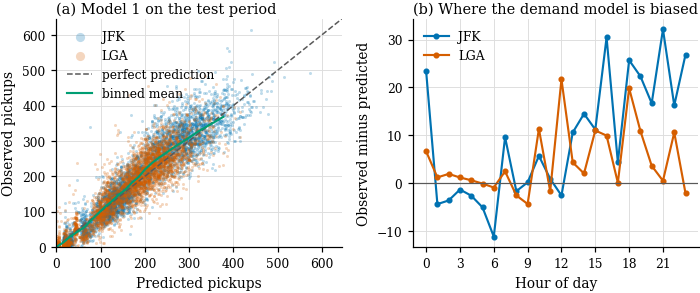

In [14]:
# --- Figure 8 --------------------------------------------------------------
fig, axes = new_figure(1, 2, height=2.9)

ax = axes[0]
for airport, group in predictions.groupby("airport"):
    ax.scatter(group["pred_pickups"], group[TARGET_VOLUME], s=4, alpha=0.25,
               linewidths=0, color=airport_colour(airport), label=airport)
limit = float(
    max(predictions["pred_pickups"].max(), predictions[TARGET_VOLUME].max())
) * 1.05
ax.plot([0, limit], [0, limit], color=BASELINE_COLOUR, lw=1.0, ls="--",
        label="perfect prediction")

# Observed mean within twenty bins of predicted demand, so that where the
# spread is off-centre is visible rather than only asserted.
binned = (
    predictions
    .groupby(
        pd.qcut(predictions["pred_pickups"], 20, duplicates="drop"),
        observed=True,
    )
    .agg(x=("pred_pickups", "mean"), y=(TARGET_VOLUME, "mean"))
)
ax.plot(binned["x"], binned["y"], color=PALETTE["green"], lw=1.4,
        label="binned mean")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("Predicted pickups")
ax.set_ylabel("Observed pickups")
ax.set_title("(a) Model 1 on the test period")
ax.legend(loc="upper left", markerscale=3)

ax = axes[1]
for airport, group in by_hour.groupby("airport"):
    ax.plot(group["hour"], group["mean_error"], marker="o", markersize=3,
            color=airport_colour(airport), label=airport)
ax.axhline(0, color=BASELINE_COLOUR, lw=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Observed minus predicted")
ax.set_title("(b) Where the demand model is biased")
ax.legend()

fig.tight_layout()
save_figure(fig, "fig08_model1_diagnostics")

### Reading the two models

**Model 1 is read as an expected day.** Every continuous feature is set to its training mean
*within the hour being predicted*, every indicator is off, and the day is an ordinary
Wednesday in June, a month inside the test window.

The alternative — holding every feature at its overall mean — is worse here. Four of the
features are the demand history, and fixing those at the daily average describes an hour
that does not occur: an 06:00 preceded by an average hour rather than by a nearly empty
05:00. Done that way the profile peaks at 06:00 and flattens the evening, contradicting
Figure 3. The hour dummies carry the daily cycle *net of* what the lags explain and are not
interpretable on their own, so the panel is described as a typical-day profile rather than
as an hour effect.

**Model 2 is read by permutation importance.** A feature is shuffled on the test set and the
increase in RMSE recorded, so what is measured is what generalises rather than what the
model memorised. The three exactly collinear flight columns are additionally permuted as a
block, since shuffling one member of a collinear group leaves it reconstructible from the
others and the per-column figures inside such a group are artefacts.


In [15]:
# Counterfactual grid: an ordinary Wednesday in June, no holiday, no rain,
# with every continuous feature at its training mean **within that
# (airport, hour) cell** rather than at its overall mean.
#
# Four of the features are the demand history, so holding them at the daily
# average would describe an hour that does not occur — an 06:00 preceded by an
# average hour rather than by a nearly empty 05:00. Conditioning on the hour
# keeps the schedule, weather, and history consistent with the hour described.
#
# June because the test period is January-June, so the reference month should
# be one the recommendations cover. Both choices are named in the caption.
REFERENCE_DAY_OF_WEEK = 3
REFERENCE_MONTH = 6
REFERENCE_MONTH_NAME = "June"
assert REFERENCE_MONTH in set(train["month"]), (
    "The reference month is not present in the training split"
)

cell_means = glm_train.groupby(["airport", "hour"])[CONTINUOUS].mean()

profile_rows = []
for airport in AIRPORTS:
    for hour in range(24):
        row = dict(cell_means.loc[(airport, hour)])
        row.update({
            "hour": hour,
            "airport": airport,
            "day_of_week": REFERENCE_DAY_OF_WEEK,
            "month": REFERENCE_MONTH,
            "is_holiday": False,
            "is_holiday_adjacent": False,
            "is_precip": False,
            "is_freezing": False,
        })
        profile_rows.append(row)

profile = pd.DataFrame(profile_rows)
profile["fitted_rate"] = np.asarray(poisson_fit.predict(profile), dtype=float)

# Named apart from the decile `peak` in Step 5, which is a different object.
peak_profile = profile.loc[profile.groupby("airport")["fitted_rate"].idxmax()]
trough_profile = profile.loc[profile.groupby("airport")["fitted_rate"].idxmin()]
print(f"Expected demand, ordinary {REFERENCE_MONTH_NAME} midweek day, "
      "average conditions for the hour")
for airport in AIRPORTS:
    high = peak_profile[peak_profile["airport"] == airport].iloc[0]
    low = trough_profile[trough_profile["airport"] == airport].iloc[0]
    print(f"  {airport}: peak {high['fitted_rate']:6.1f} pickups at "
          f"{int(high['hour']):02d}:00, trough {low['fitted_rate']:5.1f} at "
          f"{int(low['hour']):02d}:00 "
          f"({high['fitted_rate'] / max(low['fitted_rate'], 0.01):.0f}x)")

importance = permutation_importance(
    gbt, x_value_test, y_value_test, n_repeats=5,
    random_state=SEED, scoring="neg_root_mean_squared_error",
)
importances = (
    pd.DataFrame({
        "feature": x_value_test.columns,
        "rmse_increase": importance.importances_mean,
        "sd": importance.importances_std,
    })
    .sort_values("rmse_increase", ascending=False)
    .reset_index(drop=True)
)
print("\nModel 2, permutation importance on the test split (US$ of RMSE)")
print(importances.head(10).round(3).to_string(index=False))

# --- The collinear group, permuted jointly ---------------------------------
# The trees keep `arrival_slippage_lag_1h`, which the GLM design drops.
# Shuffling one member of an exactly collinear group leaves it reconstructible
# from the other two, so column-wise permutation importance reports all three
# as nearly irrelevant whatever the model does with them. The group is
# therefore permuted as a block: the rows are reordered together, which
# preserves the identity within each row and destroys only its alignment with
# the outcome.
ALIASED_GROUP = [
    "sched_arrivals_prev_hr",
    "actual_arrivals_lag_1h",
    "arrival_slippage_lag_1h",
]
group_columns = [
    column for column in ALIASED_GROUP if column in x_value_test.columns
]
base_rmse = rmse(y_value_test, gbt.predict(x_value_test))
generator = np.random.default_rng(SEED)
group_increases = []
for _ in range(5):
    shuffled = x_value_test.copy()
    order = generator.permutation(len(shuffled))
    shuffled[group_columns] = shuffled[group_columns].to_numpy()[order]
    group_increases.append(
        rmse(y_value_test, gbt.predict(shuffled)) - base_rmse
    )
group_importance = float(np.mean(group_increases))

individual = float(
    importances.loc[importances["feature"].isin(group_columns), "rmse_increase"]
    .sum()
)
print(f"\nThe three exactly collinear flight columns "
      f"({', '.join(group_columns)}) score {individual:.3f} between them when "
      f"shuffled one at a time, and ${group_importance:.3f} of RMSE when "
      "shuffled together. The second figure is the one to quote.")

Expected demand, ordinary June midweek day, average conditions for the hour
  JFK: peak  349.5 pickups at 16:00, trough  18.2 at 04:00 (19x)
  LGA: peak  250.7 pickups at 14:00, trough   1.0 at 04:00 (242x)

Model 2, permutation importance on the test split (US$ of RMSE)
                feature  rmse_increase    sd
mean_total_same_hour_7d          1.257 0.026
       mean_fare_lag_1h          1.121 0.023
                   hour          0.184 0.016
 share_flat_fare_lag_1h          0.137 0.014
    mean_total_lag_168h          0.106 0.017
mean_distance_mi_lag_1h          0.086 0.012
      sched_distance_mi          0.066 0.010
 actual_arrivals_lag_1h          0.065 0.004
            day_of_week          0.053 0.016
                airport          0.038 0.006

The three exactly collinear flight columns (sched_arrivals_prev_hr, actual_arrivals_lag_1h, arrival_slippage_lag_1h) score 0.073 between them when shuffled one at a time, and $0.095 of RMSE when shuffled together. The second figure 

Saved plots/fig09_model_interpretation.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig09_model_interpretation.png')

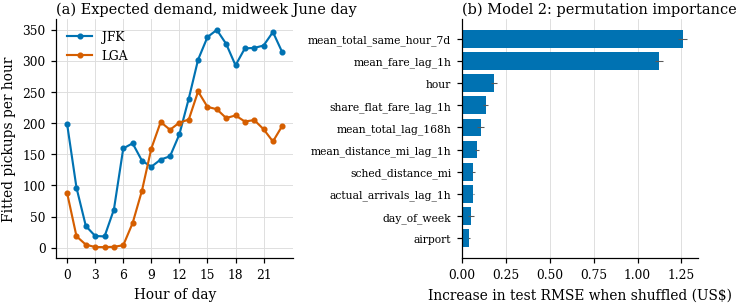

In [16]:
# --- Figure 9 --------------------------------------------------------------
fig, axes = new_figure(1, 2, height=3.0)

ax = axes[0]
for airport in AIRPORTS:
    group = profile[profile["airport"] == airport]
    ax.plot(group["hour"], group["fitted_rate"], marker="o", markersize=3,
            color=airport_colour(airport), label=airport)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fitted pickups per hour")
ax.set_title(f"(a) Expected demand, midweek {REFERENCE_MONTH_NAME} day")
ax.legend()

ax = axes[1]
top = importances.head(10).iloc[::-1]
ax.barh(top["feature"], top["rmse_increase"], xerr=top["sd"],
        color=PALETTE["blue"], error_kw={"lw": 0.7, "ecolor": PALETTE["grey"]})
ax.set_xlabel("Increase in test RMSE when shuffled (US$)")
ax.set_title("(b) Model 2: permutation importance")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=7)

fig.tight_layout()
save_figure(fig, "fig09_model_interpretation")

## Step 6 — Combining the two models

Expected revenue in an airport-hour is the product of the two predictions:

`revenue = E[pickups] × E[fare per pickup]`

Two properties of the combination are handled explicitly.

**The support.** Model 2 is undefined in hours with no pickups, and the seasonal-naive fare
forecast is undefined in a further set of hours. The product is defined everywhere — an hour
with no trips earned nothing — so the combination is evaluated on every test hour against
the product of the two naive forecasts. This is asserted rather than assumed.

**The omitted covariance term.** The identity 2c asserted holds row by row, not in
expectation:

`E[revenue | X] = E[pickups | X] × E[fare | X] + Cov(pickups, fare | X)`

A product of two separately fitted conditional means estimates only the first part. The cell
measures the second as the mean product of the two models' residuals and reports it against
the shortfall it is meant to explain, so the combination's error is attributed rather than
charged wholesale to the demand model.

**It is market revenue, not a wage.** `n_pickups × mean_total` is what every yellow taxi
collectively earned from that queue in that hour. Turning it into a driver's hourly rate
would need the queue length, which the TLC data does not record.


In [17]:
predictions["pred_revenue"] = (
    predictions["pred_pickups"] * predictions["pred_mean_total"]
)

# The seasonal-naive product: last week's count times last week's mean fare.
# Where last week's hour was empty the revenue was zero.
naive_revenue = np.where(
    predictions["pickups_lag_168h"].to_numpy() == 0,
    0.0,
    predictions["pickups_lag_168h"].to_numpy()
    * predictions["mean_total_lag_168h"].to_numpy(),
)
predictions["naive_revenue"] = naive_revenue

# The combination is scorable on every test hour. Checked rather than assumed:
# neither side may hold a null that would be silently dropped.
assert predictions["sum_total_amount"].notna().all(), (
    "sum_total_amount is null somewhere; the revenue comparison would silently "
    "drop those hours"
)
assert not pd.isna(naive_revenue).any(), "The naive revenue forecast has nulls"

revenue_metrics = {
    "benchmark": error_metrics(
        predictions["sum_total_amount"], predictions["naive_revenue"]
    ),
    "combined": error_metrics(
        predictions["sum_total_amount"], predictions["pred_revenue"]
    ),
}
revenue_improvement = 100 * (
    1 - revenue_metrics["combined"]["rmse"] / revenue_metrics["benchmark"]["rmse"]
)

observed_total = float(predictions["sum_total_amount"].sum())
predicted_total = float(predictions["pred_revenue"].sum())

assert (
    revenue_metrics["benchmark"]["n"]
    == revenue_metrics["combined"]["n"]
    == len(predictions)
), "The revenue comparison is not scored on every test hour"

print(f"Expected revenue per airport-hour, all "
      f"{revenue_metrics['combined']['n']:,} test hours — both the benchmark "
      "and the combination are defined on every one of them")
print(f"  seasonal-naive product  RMSE ${revenue_metrics['benchmark']['rmse']:,.0f}   "
      f"MAE ${revenue_metrics['benchmark']['mae']:,.0f}")
print(f"  combined models         RMSE ${revenue_metrics['combined']['rmse']:,.0f}   "
      f"MAE ${revenue_metrics['combined']['mae']:,.0f}")
print(f"  improvement in RMSE: {revenue_improvement:+.1f}%")
print(f"\nTotal observed revenue over the test period:  ${observed_total:,.0f}")
print(f"Total predicted:                              ${predicted_total:,.0f}"
      f"  ({100 * (predicted_total / observed_total - 1):+.1f}%)")

# --- The omitted covariance term -------------------------------------------
# 2c's identity holds row by row, not in expectation: the product estimates
# E[n | X] * E[mean | X] while the quantity it is scored against is
# E[n * mean | X], which exceeds it by Cov(n, mean | X). That term is
# measurable as the mean product of the two models' residuals.
#
# Measured over the hours where `mean_total` is defined, since the fare
# residual is undefined elsewhere and the empty hours contribute nothing.
defined = predictions[TARGET_VALUE].notna()
count_residual = (
    predictions.loc[defined, TARGET_VOLUME]
    - predictions.loc[defined, "pred_pickups"]
).to_numpy(dtype=float)
fare_residual = (
    predictions.loc[defined, TARGET_VALUE]
    - predictions.loc[defined, "pred_mean_total"]
).to_numpy(dtype=float)
residual_covariance = float(np.mean(count_residual * fare_residual))

mean_observed_revenue = float(predictions['sum_total_amount'].mean())
shortfall_per_hour = (observed_total - predicted_total) / len(predictions)

print(f"\nThe omitted covariance term, over the {int(defined.sum()):,} hours where "
      f"{TARGET_VALUE} is defined:")
print(f"  Cov(n_pickups, mean_total | X)   ${residual_covariance:+,.0f} "
      "per airport-hour")
print(f"  mean observed revenue            ${mean_observed_revenue:,.0f} "
      "per airport-hour")
print(f"  shortfall the combination leaves ${shortfall_per_hour:+,.0f} "
      "per airport-hour")

# Reported as a share of the level, which stays interpretable whatever sign
# the shortfall takes.
covariance_share_of_level = (
    100 * residual_covariance / mean_observed_revenue
)
if abs(covariance_share_of_level) < 2.0:
    print(f"That is {covariance_share_of_level:+.1f}% of mean revenue per hour. "
          "The two models' errors are close to uncorrelated once the features "
          "are conditioned on, so the product is a sound estimator here and the "
          "shortfall above is Model 1's bias rather than a structural defect of "
          "the combination.")
else:
    print(f"That is {covariance_share_of_level:+.1f}% of mean revenue per hour, and "
          f"{100 * residual_covariance / shortfall_per_hour:.0f}% of the shortfall. "
          "Busy hours and expensive hours co-move even after the features are "
          "accounted for, so part of the combination's error belongs to the "
          "act of multiplying two conditional means and not to either fit. "
          "Report it in the modelling section as a property of the combination, "
          "not in the limitations as a failure of a model.")


Expected revenue per airport-hour, all 8,734 test hours — both the benchmark and the combination are defined on every one of them
  seasonal-naive product  RMSE $4,175   MAE $2,834
  combined models         RMSE $3,230   MAE $2,255
  improvement in RMSE: +22.6%

Total observed revenue over the test period:  $113,419,044
Total predicted:                              $107,471,853  (-5.2%)

The omitted covariance term, over the 8,375 hours where mean_total is defined:
  Cov(n_pickups, mean_total | X)   $+24 per airport-hour
  mean observed revenue            $12,986 per airport-hour
  shortfall the combination leaves $+681 per airport-hour
That is +0.2% of mean revenue per hour. The two models' errors are close to uncorrelated once the features are conditioned on, so the product is a sound estimator here and the shortfall above is Model 1's bias rather than a structural defect of the combination.


### Step 6a — Refinement: matching the loss to the quantity

Model 2 minimises **unweighted** squared error on `mean_total`, so a 04:00 hour with two
trips weighs as much as a 17:00 hour with three hundred. The product above is revenue, where
an error in the fare is multiplied by the count, so the two objectives differ.

The chosen configuration is refitted with `n_pickups` as the sample weight. The
hyper-parameters are deliberately not re-tuned: they were selected on a forward validation
split in Step 4, and re-selecting them against a test-period objective would undo that.

Both fits are scored on the value target and on combined revenue, with Model 1 held fixed,
so the difference between the two rows is the weighting and nothing else.


In [18]:
# Same hyper-parameters, chosen in Step 4 on a forward validation split, and
# deliberately not re-tuned against a test-period objective.
gbt_weighted = HistGradientBoostingRegressor(
    random_state=SEED, early_stopping=False, **best
)
gbt_weighted.fit(
    x_value_train,
    y_value_train,
    sample_weight=value_train[TARGET_VOLUME].to_numpy(dtype=float),
)

weighted_value = error_metrics(
    y_value_test, gbt_weighted.predict(x_value_test)
)

# Model 1's predictions are held fixed, so the difference between the two
# rows below is the weighting and nothing else.
weighted_revenue_prediction = (
    predictions["pred_pickups"].to_numpy(dtype=float)
    * gbt_weighted.predict(design_matrix(test, MODEL_2_FEATURES))
)
weighted_revenue = error_metrics(
    predictions["sum_total_amount"], weighted_revenue_prediction
)

refinement = pd.DataFrame([
    {
        "weighting": "unweighted",
        "value_rmse": value_metrics["gbt_full_support"]["rmse"],
        "revenue_rmse": revenue_metrics["combined"]["rmse"],
    },
    {
        "weighting": f"weighted by {TARGET_VOLUME}",
        "value_rmse": weighted_value["rmse"],
        "revenue_rmse": weighted_revenue["rmse"],
    },
])
print("Model 2 under two loss weightings, test period. `value_rmse` is US$ per "
      "trip over all\n"
      f"{weighted_value['n']:,} hours where {TARGET_VALUE} is defined; "
      "`revenue_rmse` is US$ per airport-hour\nover all "
      f"{revenue_metrics['combined']['n']:,} test hours, with Model 1 held "
      "fixed.")
print(refinement.to_string(index=False))

# The verdict follows the computed figures. Both are stated as improvements,
# positive meaning the weighted fit is better, so the two signs agree.
revenue_gain = 100 * (
    1 - weighted_revenue["rmse"] / revenue_metrics["combined"]["rmse"]
)
value_gain = 100 * (
    1 - weighted_value["rmse"] / value_metrics["gbt_full_support"]["rmse"]
)
if revenue_gain > 1:
    print(f"\nWeighting improves combined revenue RMSE by {revenue_gain:+.1f}% "
          f"and the per-trip fare by {value_gain:+.1f}% (positive is better on "
          "both). The two serve different questions, so both are reported: the "
          "unweighted model for what a trip is worth, the weighted one for "
          "what a queue produces.")
elif revenue_gain < -1:
    print(f"\nWeighting makes combined revenue RMSE {abs(revenue_gain):.1f}% "
          f"worse and moves the per-trip fare by {value_gain:+.1f}% (positive "
          "is better). The "
          "unweighted fit is therefore kept throughout, and the choice is now "
          "a tested one rather than a default.")
else:
    print(f"\nWeighting moves combined revenue RMSE by {revenue_gain:+.1f}% "
          f"and the per-trip fare by {value_gain:+.1f}% (positive is better on "
          "both) — neither materially, and both in the same direction. The "
          "fare surface is close to flat in the weighting, so the choice of "
          "loss does not decide anything here. The unweighted fit is kept "
          "because it is the one already read on its own in Step 7, and the "
          "insensitivity is itself worth one sentence: the combination is "
          "robust to which of the two objectives Model 2 is fitted to.")


Model 2 under two loss weightings, test period. `value_rmse` is US$ per trip over all
8,375 hours where mean_total is defined; `revenue_rmse` is US$ per airport-hour
over all 8,734 test hours, with Model 1 held fixed.
            weighting  value_rmse  revenue_rmse
           unweighted       8.432      3230.254
weighted by n_pickups       8.356      3222.253

Weighting moves combined revenue RMSE by +0.2% and the per-trip fare by +0.9% (positive is better on both) — neither materially, and both in the same direction. The fare surface is close to flat in the weighting, so the choice of loss does not decide anything here. The unweighted fit is kept because it is the one already read on its own in Step 7, and the insensitivity is itself worth one sentence: the combination is robust to which of the two objectives Model 2 is fitted to.


Saved plots/fig10_expected_revenue.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig10_expected_revenue.png')

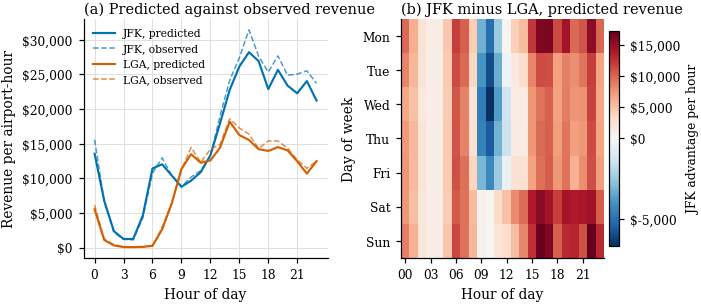

In [19]:
# Predicted revenue per queue, averaged over the six test months, by hour of
# day and day of week.
DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
HOUR_LABELS = [f"{hour:02d}" for hour in range(24)]

surface = (
    predictions.groupby(["airport", "day_of_week", "hour"])
    .agg(
        pred_revenue=("pred_revenue", "mean"),
        pred_fare=("pred_mean_total", "mean"),
        pred_pickups=("pred_pickups", "mean"),
        observed_revenue=("sum_total_amount", "mean"),
    )
    .reset_index()
)


def surface_grid(frame: pd.DataFrame, airport: str, value: str) -> np.ndarray:
    """Reshape one airport's surface into a 7 × 24 grid, Monday first."""
    grid = (
        frame[frame["airport"] == airport]
        .pivot_table(index="day_of_week", columns="hour", values=value)
        .reindex(index=range(1, 8), columns=range(24))
    )
    return grid.to_numpy()


advantage = (
    surface_grid(surface, AIRPORTS[0], "pred_revenue")
    - surface_grid(surface, AIRPORTS[1], "pred_revenue")
)

hourly = (
    predictions.groupby(["airport", "hour"])
    .agg(
        predicted=("pred_revenue", "mean"),
        observed=("sum_total_amount", "mean"),
        fare=("pred_mean_total", "mean"),
    )
    .reset_index()
)

# --- Figure 10 -------------------------------------------------------------
fig, axes = new_figure(1, 2, height=3.0)

ax = axes[0]
for airport in AIRPORTS:
    group = hourly[hourly["airport"] == airport]
    ax.plot(group["hour"], group["predicted"], color=airport_colour(airport),
            label=f"{airport}, predicted")
    ax.plot(group["hour"], group["observed"], color=airport_colour(airport),
            ls="--", lw=1.0, alpha=0.7, label=f"{airport}, observed")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Revenue per airport-hour")
ax.set_title("(a) Predicted against observed revenue")
currency_axis(ax)
ax.legend(fontsize=7)

ax = axes[1]
# Diverging scale anchored at zero but not symmetric. One airport's advantage
# is several times larger in magnitude than the other's, so a symmetric scale
# would spend half its range on values that never occur. Zero stays at the
# neutral midpoint; only the two sides get different amounts of range.
finite = advantage[np.isfinite(advantage)]
norm = TwoSlopeNorm(
    vmin=min(float(finite.min()), -1.0),
    vcenter=0.0,
    vmax=max(float(finite.max()), 1.0),
)
image = heatmap(
    ax, advantage, DAY_LABELS, HOUR_LABELS, cmap=DIVERGING_CMAP, norm=norm,
    title=f"(b) {AIRPORTS[0]} minus {AIRPORTS[1]}, predicted revenue",
    xlabel="Hour of day", ylabel="Day of week",
)
bar = fig.colorbar(image, ax=ax, shrink=0.9, pad=0.02)
bar.set_label(f"{AIRPORTS[0]} advantage per hour", size=8)
currency_axis(bar.ax)

fig.tight_layout()
save_figure(fig, "fig10_expected_revenue")

## Step 7 — The combined surface, by hour and day

The predicted revenue surface is read off by airport, hour of day, and day of week: the
highest-revenue hours per airport, the hours and the specific day-hour cells where the
smaller airport is predicted to out-earn the larger, and the predicted fare per trip by hour.

The comparison between two airports in the same hour is made under the assumption that the
two queues are comparably supplied, since the data records trips rather than waiting taxis
and no model here observes queue length.


In [20]:
best_hours = (
    hourly.sort_values("predicted", ascending=False)
    .groupby("airport")
    .head(5)
    .sort_values(["airport", "predicted"], ascending=[True, False])
)
print("Highest predicted revenue per hour, by airport (test-period average)")
print(best_hours.round(1).to_string(index=False))

# Hours where the smaller airport is predicted to be worth more.
wide = hourly.pivot(index="hour", columns="airport", values="predicted")
fare_wide = hourly.pivot(index="hour", columns="airport", values="fare")
crossover = wide[wide[AIRPORTS[1]] > wide[AIRPORTS[0]]]
print(f"\nHours where {AIRPORTS[1]} is predicted to out-earn {AIRPORTS[0]}, "
      f"pooled across the week: {list(crossover.index)}")

# The same crossover at day-hour resolution, read off the surface the heatmap
# draws, since the pooled figure hides whether the advantage is spread evenly
# across the week.
cell_wide = surface.pivot_table(
    index=["day_of_week", "hour"], columns="airport", values="pred_revenue"
)
cell_crossover = (
    cell_wide[cell_wide[AIRPORTS[1]] > cell_wide[AIRPORTS[0]]]
    .assign(advantage=lambda frame: frame[AIRPORTS[1]] - frame[AIRPORTS[0]])
    .reset_index()
)
cell_crossover["day"] = cell_crossover["day_of_week"].map(
    dict(enumerate(DAY_LABELS, start=1))
)
crossover_days = [
    DAY_LABELS[day - 1] for day in sorted(cell_crossover["day_of_week"].unique())
]
print(f"\nDay-hour cells where {AIRPORTS[1]} out-earns {AIRPORTS[0]} "
      f"({len(cell_crossover)} of {len(cell_wide)}), by size of the advantage")
print(
    cell_crossover.sort_values("advantage", ascending=False)
    [["day", "hour", "advantage"]].round(0).to_string(index=False)
)
print(f"Days involved: {', '.join(crossover_days)} — the advantage is not "
      "spread evenly across the week, so the recommendation should name the "
      "days rather than the hours alone.")
print("\nPredicted fare per trip, by hour (US$)")
print(fare_wide.round(2).to_string())

Highest predicted revenue per hour, by airport (test-period average)
airport  hour  predicted  observed  fare
    JFK    16    28213.6   31439.1  87.6
    JFK    17    26932.8   27640.4  87.1
    JFK    15    26142.3   27397.5  84.7
    JFK    19    25662.3   27680.5  84.5
    JFK    22    24042.7   25524.1  79.8
    LGA    14    18183.6   18590.0  69.0
    LGA    15    16246.5   17257.8  69.1
    LGA    16    15536.3   16381.2  70.5
    LGA    19    14510.3   15390.7  65.6
    LGA    13    14416.0   14904.3  68.3

Hours where LGA is predicted to out-earn JFK, pooled across the week: [9, 10, 11]

Day-hour cells where LGA out-earns JFK (19 of 168), by size of the advantage
day  hour  advantage
Wed    10     6668.0
Tue    10     5900.0
Thu    10     5540.0
Mon    10     5049.0
Wed     9     4616.0
Thu     9     4508.0
Fri    10     4321.0
Tue     9     3954.0
Wed    11     3716.0
Tue    11     3334.0
Mon     9     3227.0
Thu    11     3128.0
Fri     9     3027.0
Mon    11     2496.0
Fri 

In [21]:
# --- Persist ---------------------------------------------------------------
# `remove_data=True` drops the cached design matrix and endog/exog arrays,
# which are ~36MB per fit and are never read back: the artefact of record for
# the GLM is the coefficient table written below. Inference objects (params,
# bse, pvalues, conf_int) all survive, so a reader can still inspect the fit.
quasi_fit.save(
    str(MODELS_DIR / "poisson_glm_quasi.pickle"), remove_data=True
)
negbin_fit.save(
    str(MODELS_DIR / "negative_binomial_glm.pickle"), remove_data=True
)
joblib.dump(gbt, MODELS_DIR / "gbt_value.joblib")
joblib.dump(gbt_weighted, MODELS_DIR / "gbt_value_weighted.joblib")

# Coefficients with quasi-Poisson inference, exponentiated into rate ratios.
coefficients = pd.DataFrame({
    "term": quasi_fit.params.index,
    "coefficient": quasi_fit.params.to_numpy(),
    "std_error": quasi_fit.bse.to_numpy(),
    "p_value": quasi_fit.pvalues.to_numpy(),
    "rate_ratio": np.exp(quasi_fit.params.to_numpy()),
})
confidence = quasi_fit.conf_int()
coefficients["rate_ratio_low"] = np.exp(confidence[0].to_numpy())
coefficients["rate_ratio_high"] = np.exp(confidence[1].to_numpy())
coefficients.to_csv(MODELS_DIR / "glm_coefficients.csv", index=False)

KEEP = [
    "date", "hour", "airport", TARGET_VOLUME, TARGET_VALUE, "sum_total_amount",
    "pred_pickups", "pred_pickups_nb", "pred_mean_total", "pred_revenue",
    "naive_revenue", "residual",
]
predictions[KEEP].to_parquet(
    CURATED_DIR / "model_predictions.parquet", index=False
)

model_results = {
    "split": {
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        "excluded_rows": int(excluded),
        "model_2_train_rows": int(len(value_train)),
        "model_2_test_rows": int(len(value_test)),
    },
    "model_1": {
        "family": "Poisson GLM, log link, quasi-Poisson scale",
        "parameters": int(poisson_fit.df_model) + 1,
        "design_columns": int(design.shape[1]),
        "design_rank": design_rank,
        "dropped_as_aliased": ALIASED_IN_GLM,
        "pearson_dispersion": round(pearson_dispersion, 3),
        "negative_binomial_alpha": round(alpha, 4),
        "test": volume_metrics,
        "test_mean_poisson_deviance": {
            key: round(value, 4) for key, value in deviance.items()
        },
        "carried_into_recommendations": rmse_winner,
    },
    "model_2": {
        "family": "HistGradientBoostingRegressor",
        "hyperparameters": best,
        "validation_rmse": float(tuning.loc[0, "valid_rmse"]),
        "test": value_metrics,
        "top_features": importances.head(5)["feature"].tolist(),
        "collinear_group_importance": {
            "columns": group_columns,
            "shuffled_individually_summed": round(individual, 3),
            "shuffled_as_a_group": round(group_importance, 3),
        },
        "weighted_refinement": {
            "weight": TARGET_VOLUME,
            "value_rmse": weighted_value["rmse"],
            "revenue_rmse": weighted_revenue["rmse"],
            "unweighted_value_rmse": value_metrics["gbt_full_support"]["rmse"],
            "unweighted_revenue_rmse": revenue_metrics["combined"]["rmse"],
        },
    },
    "combined": {
        "test": revenue_metrics,
        "rmse_improvement_pct": round(revenue_improvement, 1),
        "observed_test_revenue": round(observed_total, 2),
        "predicted_test_revenue": round(predicted_total, 2),
        "residual_covariance_per_hour": round(residual_covariance, 2),
        "shortfall_per_hour": round(shortfall_per_hour, 2),
        "covariance_share_of_mean_revenue_pct": round(
            covariance_share_of_level, 3
        ),
    },
    # Written out rather than retyped from a printed cell, so a quoted figure
    # cannot drift from the code that produced it.
    "recommendations": {
        "peak_hours": {
            airport: [
                {
                    "hour": int(row.hour),
                    "predicted_revenue": round(float(row.predicted), 2),
                    "observed_revenue": round(float(row.observed), 2),
                    "predicted_fare": round(float(row.fare), 2),
                }
                for row in best_hours[
                    best_hours["airport"] == airport
                ].itertuples()
            ]
            for airport in AIRPORTS
        },
        "hours_second_airport_out_earns_first": {
            "first": AIRPORTS[0],
            "second": AIRPORTS[1],
            "hours": [int(hour) for hour in crossover.index],
            "day_hour_cells": [
                {
                    "day": row.day,
                    "hour": int(row.hour),
                    "advantage": round(float(row.advantage), 2),
                }
                for row in cell_crossover.sort_values(
                    "advantage", ascending=False
                ).itertuples()
            ],
            "days": crossover_days,
        },
        "predicted_fare_by_hour": {
            airport: {
                str(int(hour)): round(float(value), 2)
                for hour, value in fare_wide[airport].items()
            }
            for airport in AIRPORTS
        },
    },
    # The error analysis, in the same form.
    "error_analysis": {
        "mean_residual_pickups": round(mean_bias, 2),
        "residual_by_test_month": {
            str(int(month)): round(float(value), 2)
            for month, value in horizon.items()
        },
        "residual_by_predicted_decile": {
            str(int(decile)): round(float(value), 2)
            for decile, value in by_decile["mean_error"].items()
        },
        "decile_rank_correlation": round(decile_trend, 3),
        "year_on_year_demand_pct": round(level_shift_pct, 2),
        "residual_vs_schedule_change_correlation": round(
            schedule_correlation, 3
        ),
        "residual_vs_conversion_change_correlation": round(
            conversion_correlation, 3
        ),
        "conversion_cells_with_domestic_base": int(
            conversion["supported"].sum()
        ),
        "conversion_cells_total": int(len(conversion)),
        "lag_1_autocorrelation": {
            airport: round(
                float(
                    group.sort_values(["date", "hour"])["residual"].autocorr(
                        lag=1
                    )
                ),
                3,
            )
            for airport, group in predictions.groupby("airport")
        },
    },
}
with open(CURATED_DIR / "model_results.json", "w") as handle:
    json.dump(model_results, handle, indent=2)

print(f"Models written to {MODELS_DIR}")
print(f"Predictions and metrics written to {CURATED_DIR}")
for path in sorted(PLOTS_DIR.glob("fig*.png")):
    print(f"  {path.name}")

Models written to /home/tavish/projects/project-1-individual-SavvyHack/models
Predictions and metrics written to /home/tavish/projects/project-1-individual-SavvyHack/data/curated
  fig01_fare_distribution.png
  fig02_target_distribution.png
  fig03_hour_weekday_heatmaps.png
  fig04_flights_to_pickups.png
  fig05_weather.png
  fig06_dropoff_geography.png
  fig07_rehail_tradeoff.png
  fig08_model1_diagnostics.png
  fig09_model_interpretation.png
  fig10_expected_revenue.png


## References

1. McCullagh, P. and Nelder, J. A. *Generalized Linear Models*, 2nd ed. Chapman and Hall,
   1989 — the Poisson GLM and the log link.
2. Cameron, A. C. and Trivedi, P. K. *Regression Analysis of Count Data*, 2nd ed. Cambridge
   University Press, 2013 — overdispersion, the quasi-Poisson scale, and the auxiliary
   regression used to estimate the negative binomial dispersion.
3. Friedman, J. H. "Greedy function approximation: a gradient boosting machine."
   *Annals of Statistics*, 29(5), 2001 — gradient boosting.
4. Pedregosa, F. et al. "Scikit-learn: Machine Learning in Python." *Journal of Machine
   Learning Research*, 12, 2011 — `HistGradientBoostingRegressor` and
   `permutation_importance`.
5. Seabold, S. and Perktold, J. "statsmodels: Econometric and statistical modeling with
   Python." *Proceedings of the 9th Python in Science Conference*, 2010.
